In [4]:
%pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 41.7 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 37.9 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]2m1/2 [pandas]
Note: you may need to restart the kernel to use updated packages.


In [4]:
# Importamos pandas para trabajar con los datos
import pandas as pd

# Cargamos la base de datos
df = pd.read_csv("weekly_ae_activity_20260920.csv")

# Mostramos los primeros cinco registros
df.head()

,WeekEndingDate,Country,HBT,TreatmentLocation,DepartmentType,AttendanceCategory,NumberOfAttendancesEpisode,NumberWithin4HoursEpisode,NumberOver4HoursEpisode,PercentageWithin4HoursEpisode,NumberOver8HoursEpisode,PercentageOver8HoursEpisode,NumberOver12HoursEpisode,PercentageOver12HoursEpisode
0,20150222,S92000003,S08000015,A210H,Type 1,Unplanned,814,624,190,76.7,21,2.6,2,0.2
1,20150222,S92000003,S08000015,A210H,Type 1,All,814,624,190,76.7,21,2.6,2,0.2
2,20150222,S92000003,S08000015,A111H,Type 1,Unplanned,1347,1115,232,82.8,31,2.3,2,0.1
3,20150222,S92000003,S08000015,A111H,Type 1,All,1347,1115,232,82.8,31,2.3,2,0.1
4,20150222,S92000003,S08000016,B120H,Type 1,Unplanned,517,463,54,89.6,1,0.2,0,0.0


In [5]:
# Tamaño de la base
print("Filas y columnas:", df.shape)

# Valores faltantes por columna
print("\nValores faltantes:")
print(df.isna().sum())

# Registros duplicados
print("\nDuplicados:", df.duplicated().sum())

# Categorías de atención
print("\nCategorías:")
print(df["AttendanceCategory"].value_counts())

Filas y columnas: (42915, 14)

Valores faltantes:
WeekEndingDate                   0
Country                          0
HBT                              0
TreatmentLocation                0
DepartmentType                   0
AttendanceCategory               0
NumberOfAttendancesEpisode       0
NumberWithin4HoursEpisode        0
NumberOver4HoursEpisode          0
PercentageWithin4HoursEpisode    0
NumberOver8HoursEpisode          0
PercentageOver8HoursEpisode      0
NumberOver12HoursEpisode         0
PercentageOver12HoursEpisode     0
dtype: int64

Duplicados: 0

Categorías:
AttendanceCategory
Unplanned      18179
All            18179
New planned     6557
Name: count, dtype: int64


In [6]:
# Seleccionamos las atenciones no programadas
urgencias = df[df["AttendanceCategory"] == "Unplanned"].copy()

# Convertimos las fechas
urgencias["WeekEndingDate"] = pd.to_datetime(
    urgencias["WeekEndingDate"].astype(str),
    format="%Y%m%d"
)

# Calculamos el total semanal de las ubicaciones incluidas
demanda_semanal = (
    urgencias.groupby("WeekEndingDate")["NumberOfAttendancesEpisode"]
    .sum(min_count=1)
    .sort_index()
    .to_frame(name="Atenciones")
    .asfreq("W-SUN")
)

print("Número de semanas:", len(demanda_semanal))
print("Inicio:", demanda_semanal.index.min())
print("Fin:", demanda_semanal.index.max())
print("Semanas sin datos:", demanda_semanal["Atenciones"].isna().sum())

demanda_semanal.head()

Número de semanas: 605
Inicio: 2015-02-22 00:00:00
Fin: 2026-09-20 00:00:00
Semanas sin datos: 0


,Atenciones
WeekEndingDate,
2015-02-22,25513
2015-03-01,25401
2015-03-08,25151
2015-03-15,25238
2015-03-22,26247


In [7]:
print("Número de semanas:", len(demanda_semanal))
print("Inicio:", demanda_semanal.index.min())
print("Fin:", demanda_semanal.index.max())
print("Semanas sin datos:", demanda_semanal["Atenciones"].isna().sum())

Número de semanas: 605
Inicio: 2015-02-22 00:00:00
Fin: 2026-09-20 00:00:00
Semanas sin datos: 0


In [8]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


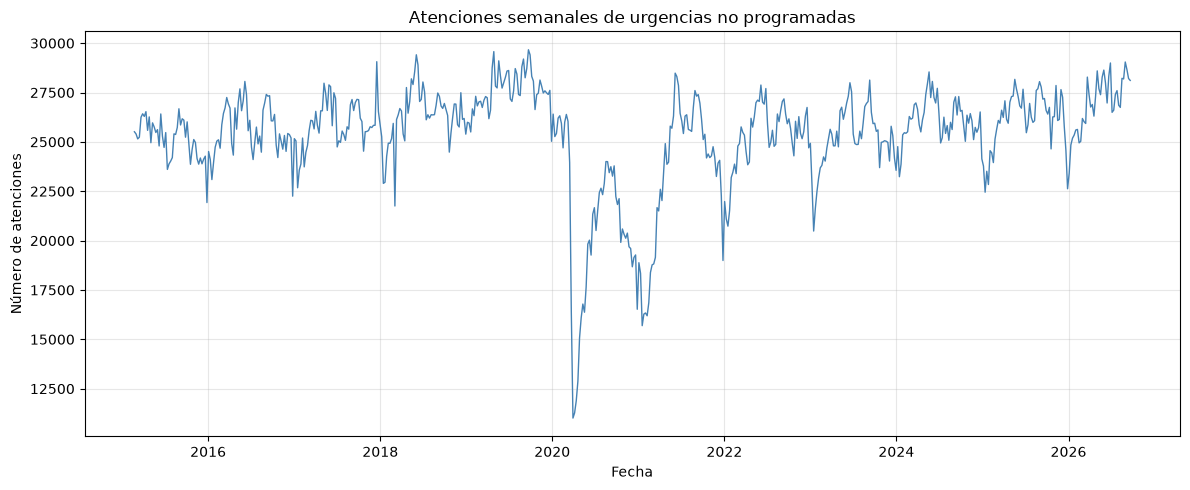

In [9]:
import matplotlib.pyplot as plt

# Graficamos las atenciones semanales
plt.figure(figsize=(12, 5))

plt.plot(
    demanda_semanal.index,
    demanda_semanal["Atenciones"],
    color="steelblue",
    linewidth=1
)

plt.title("Atenciones semanales de urgencias no programadas")
plt.xlabel("Fecha")
plt.ylabel("Número de atenciones")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Mínimo de hospitales por semana: 30
Máximo de hospitales por semana: 32


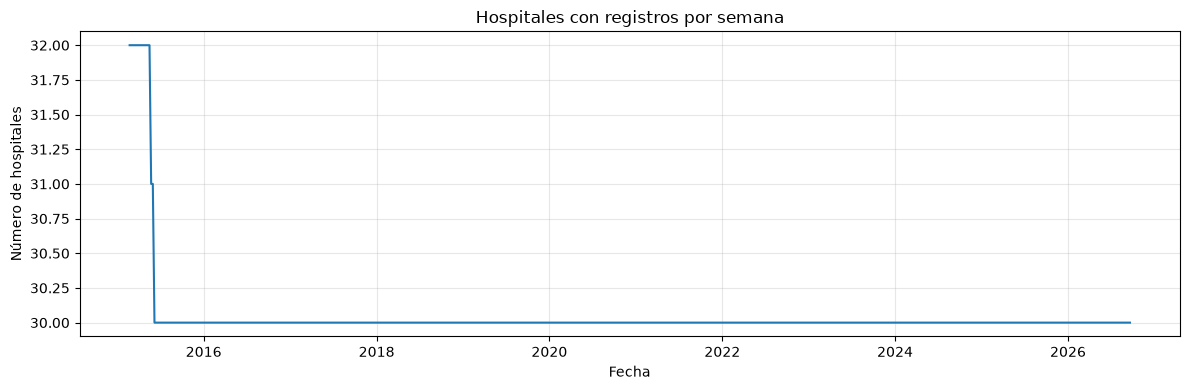

In [10]:
cobertura = (
    urgencias.groupby("WeekEndingDate")["TreatmentLocation"]
    .nunique()
    .sort_index()
)

print("Mínimo de hospitales por semana:", cobertura.min())
print("Máximo de hospitales por semana:", cobertura.max())

plt.figure(figsize=(12, 4))
plt.plot(cobertura.index, cobertura.values)
plt.title("Hospitales con registros por semana")
plt.xlabel("Fecha")
plt.ylabel("Número de hospitales")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
### Demanda semanal y cobertura

La demanda presenta una caída pronunciada en 2020 y una recuperación posterior. El número de centros con registros disminuye de 32 a 30 al inicio de la serie y después permanece estable.

La caída de 2020 no coincide con una reducción del número de centros registrados. Sin embargo, este conteo no confirma que sean siempre los mismos centros ni permite determinar la causa del cambio en la demanda.

In [12]:

demanda = demanda_semanal["Atenciones"]

print("Resumen de atenciones semanales:")
print(demanda.describe().round(2))

cv = demanda.std() / demanda.mean() * 100
print("\nCoeficiente de variación:", round(cv, 2), "%")

print("\n5 semanas con mayor demanda:")
print(demanda.nlargest(5))

print("\n5 semanas con menor demanda:")
print(demanda.nsmallest(5))

Resumen de atenciones semanales:
count      605.00
mean     25355.38
std       2589.88
min      11012.00
25%      24739.00
50%      25856.00
75%      26913.00
max      29666.00
Name: Atenciones, dtype: float64

Coeficiente de variación: 10.21 %

5 semanas con mayor demanda:
WeekEndingDate
2019-09-22    29666
2019-04-28    29573
2018-06-03    29411
2019-09-29    29405
2019-09-01    29196
Name: Atenciones, dtype: int64

5 semanas con menor demanda:
WeekEndingDate
2020-03-29    11012
2020-04-05    11274
2020-04-12    11887
2020-04-19    12884
2020-04-26    15071
Freq: W-SUN, Name: Atenciones, dtype: int64


### Variación de la demanda semanal

En las 605 semanas analizadas, el promedio fue de 25,355.38 atenciones semanales, con una desviación estándar de 2,589.88 y un coeficiente de variación de 10.21%.

El 50% central de las semanas registró entre 24,739 y 26,913 atenciones. El máximo fue de 29,666 en la semana terminada el 22 de septiembre de 2019; el mínimo fue de 11,012 en la semana terminada el 29 de marzo de 2020.

Estos resultados describen toda la serie. El coeficiente de variación incluye cambios entre años y no representa el error de los futuros pronósticos.

In [13]:
resumen_anual = demanda.groupby(demanda.index.year).agg(
    ["count", "mean", "std", "min", "max"]
)

resumen_anual.columns = [
    "Semanas", "Promedio", "Desviación", "Mínimo", "Máximo"
]
resumen_anual.index.name = "Año"

display(resumen_anual.round(2))

,Semanas,Promedio,Desviación,Mínimo,Máximo
Año,,,,,
2015,45,25139.93,983.81,21927,26677
2016,52,25630.40,1248.15,22251,28062
2017,53,25910.47,1196.73,22676,29061
2018,52,26306.85,1427.37,21752,29411
2019,52,27625.29,1018.11,25030,29666
2020,52,20868.81,4021.38,11012,26406
2021,52,23436.38,3580.72,15692,28481
2022,52,25300.29,1607.18,20732,27879
2023,53,25179.87,1502.09,20484,28130


### Comparación por año

El promedio semanal pasó de 27,625.29 atenciones en 2019 a 20,868.81 en 2020. Además, 2020 presentó la mayor desviación estándar: 4,021.38 atenciones.

Después se observa una recuperación, aunque no es continua: el promedio fue de 25,300.29 en 2022, 25,179.87 en 2023 y 26,151.71 en 2025.

Los años 2015 y 2026 contienen 45 y 38 semanas, respectivamente. Sus promedios corresponden a periodos parciales y deben compararse con cautela.

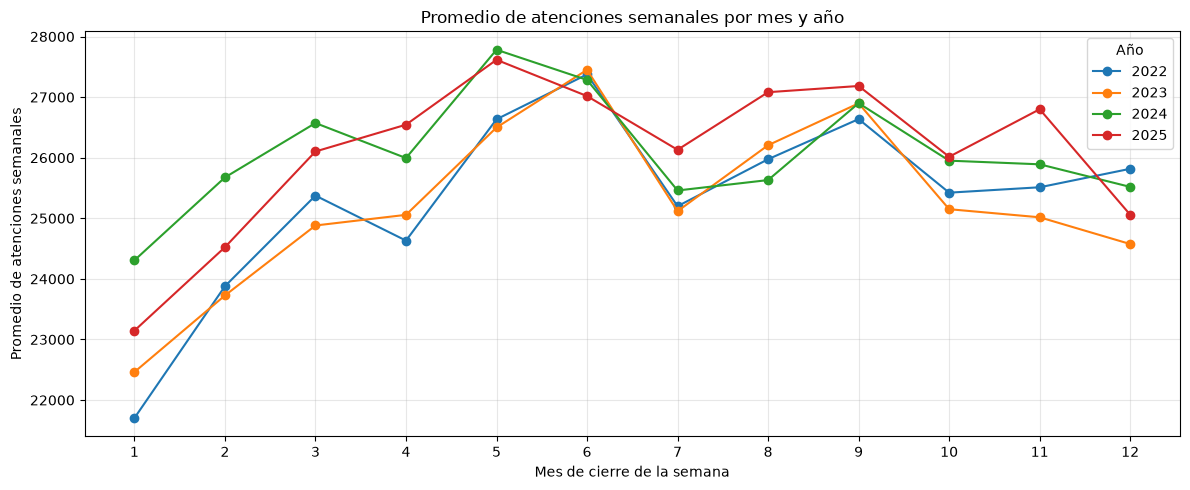

In [14]:
# Años completos recientes para explorar patrones mensuales
datos_mensuales = demanda_semanal.loc["2022":"2025"].copy()
datos_mensuales["Año"] = datos_mensuales.index.year
datos_mensuales["Mes"] = datos_mensuales.index.month

patron_mensual = datos_mensuales.pivot_table(
    index="Mes",
    columns="Año",
    values="Atenciones",
    aggfunc="mean"
)

patron_mensual.plot(figsize=(12, 5), marker="o")
plt.title("Promedio de atenciones semanales por mes y año")
plt.xlabel("Mes de cierre de la semana")
plt.ylabel("Promedio de atenciones semanales")
plt.xticks(range(1, 13))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Exploración de patrones estacionales

Entre 2022 y 2025, enero presenta el menor promedio de atenciones semanales en cada año. La demanda aumenta hacia mayo y junio, disminuye en julio y vuelve a subir en septiembre.

La repetición de estos movimientos sugiere un patrón estacional anual, aunque su intensidad cambia entre años. Se compararán modelos con y sin estacionalidad para evaluar si incorporarla mejora los pronósticos.

### División para evaluar los pronósticos

Se reservan las últimas 52 semanas para prueba y las 52 anteriores para validación. El resto se utiliza como entrenamiento.

La validación permite comparar modelos y elegir sus parámetros. La prueba se reserva para evaluar el modelo seleccionado. Cada pronóstico estimará una semana usando únicamente información de semanas anteriores.

In [15]:
serie = demanda_semanal["Atenciones"].astype(float).copy()

assert serie.isna().sum() == 0, "Hay semanas sin datos."

train = serie.iloc[:-104]
valid = serie.iloc[-104:-52]
test = serie.iloc[-52:]

division = pd.DataFrame({
    "Conjunto": ["Entrenamiento", "Validación", "Prueba"],
    "Semanas": [len(train), len(valid), len(test)],
    "Inicio": [
        train.index.min(),
        valid.index.min(),
        test.index.min()
    ],
    "Fin": [
        train.index.max(),
        valid.index.max(),
        test.index.max()
    ]
})

display(division)

,Conjunto,Semanas,Inicio,Fin
0,Entrenamiento,501,2015-02-22,2024-09-22
1,Validación,52,2024-09-29,2025-09-21
2,Prueba,52,2025-09-28,2026-09-20


In [16]:
# Usamos entrenamiento y validación; la prueba queda reservada
historial = pd.concat([train, valid])

pred_valid = pd.DataFrame({
    "Real": valid,
    "Ingenuo": historial.shift(1).loc[valid.index],
    "Ingenuo estacional": historial.shift(52).loc[valid.index],
    "Promedio móvil 4": (
        historial.shift(1).rolling(4).mean().loc[valid.index]
    )
})

# Error = real - pronóstico
resultados = []

for modelo in pred_valid.columns.drop("Real"):
    error = pred_valid["Real"] - pred_valid[modelo]

    resultados.append({
        "Modelo": modelo,
        "MD": error.mean(),
        "MAD": error.abs().mean(),
        "MAPE (%)": (
            error.abs() / pred_valid["Real"]
        ).mean() * 100,
        "RMSE": (error.pow(2).mean()) ** 0.5
    })

metricas_valid = (
    pd.DataFrame(resultados)
    .set_index("Modelo")
    .sort_values("MAD")
)

display(metricas_valid.round(2))

,MD,MAD,MAPE (%),RMSE
Modelo,,,,
Ingenuo,-1.90,643.33,2.50,799.57
Promedio móvil 4,19.51,751.51,2.93,914.19
Ingenuo estacional,215.23,782.88,3.03,966.62


### Resultados de los modelos de referencia

El modelo ingenuo presentó los menores errores en validación: MAD de 643.33 atenciones, MAPE de 2.50% y RMSE de 799.57.

Su MD de −1.90 indica un sesgo promedio cercano a cero, aunque los errores positivos y negativos pueden cancelarse.

El promedio móvil de cuatro semanas y el ingenuo estacional obtuvieron errores mayores. Por ahora, utilizar la demanda de la semana anterior es la mejor referencia para evaluar los siguientes modelos.

Estos resultados corresponden a pronósticos de una semana adelante durante las 52 semanas de validación.

In [17]:
# Probamos distintos valores de alpha en validación
resultados_ses = []
pronosticos_ses = {}

for alpha in [0.1, 0.3, 0.5, 0.7, 0.9]:
    # El nivel inicial usa únicamente entrenamiento
    nivel = train.iloc[0]

    for real in train.iloc[1:]:
        nivel = alpha * real + (1 - alpha) * nivel

    predicciones = []

    for real in valid:
        # Primero pronosticamos; después conocemos el valor real
        predicciones.append(nivel)
        nivel = alpha * real + (1 - alpha) * nivel

    pred = pd.Series(predicciones, index=valid.index)
    pronosticos_ses[alpha] = pred
    error = valid - pred

    resultados_ses.append({
        "Alpha": alpha,
        "MD": error.mean(),
        "MAD": error.abs().mean(),
        "MAPE (%)": (error.abs() / valid).mean() * 100,
        "RMSE": (error.pow(2).mean()) ** 0.5
    })

tabla_ses = (
    pd.DataFrame(resultados_ses)
    .set_index("Alpha")
    .sort_values("MAD")
)

display(tabla_ses.round(2))

,MD,MAD,MAPE (%),RMSE
Alpha,,,,
0.7,4.56,633.61,2.46,780.05
0.9,-0.23,634.73,2.47,785.54
0.5,14.63,652.83,2.54,807.69
0.3,39.67,720.22,2.81,892.05
0.1,101.64,903.17,3.52,1127.06


### Suavización exponencial simple

Entre los valores de alpha evaluados, 0.7 obtuvo el menor MAD: 633.61 atenciones. Su MAPE fue de 2.46% y su RMSE de 780.05.

El MAD disminuyó aproximadamente 1.51% respecto al modelo ingenuo. La mejora es pequeña y corresponde únicamente al periodo de validación.

Se conserva alpha = 0.7 como candidato para la comparación final. Todavía falta evaluar modelos que incorporen tendencia y estacionalidad.

In [18]:
resultados_holt = []
pronosticos_holt = {}

for alpha in [0.1, 0.3, 0.5, 0.7, 0.9]:
    for beta in [0.1, 0.3, 0.5]:
        # Inicialización con las primeras dos semanas de entrenamiento
        nivel = train.iloc[1]
        tendencia = train.iloc[1] - train.iloc[0]

        # Actualizamos los estados con el resto del entrenamiento
        for real in train.iloc[2:]:
            nivel_anterior = nivel
            nivel = alpha * real + (1 - alpha) * (
                nivel + tendencia
            )
            tendencia = beta * (nivel - nivel_anterior) + (
                1 - beta
            ) * tendencia

        predicciones = []

        for real in valid:
            # Pronóstico antes de incorporar el valor real
            predicciones.append(nivel + tendencia)

            nivel_anterior = nivel
            nivel = alpha * real + (1 - alpha) * (
                nivel + tendencia
            )
            tendencia = beta * (nivel - nivel_anterior) + (
                1 - beta
            ) * tendencia

        pred = pd.Series(predicciones, index=valid.index)
        pronosticos_holt[(alpha, beta)] = pred
        error = valid - pred

        resultados_holt.append({
            "Alpha": alpha,
            "Beta": beta,
            "MD": error.mean(),
            "MAD": error.abs().mean(),
            "MAPE (%)": (error.abs() / valid).mean() * 100,
            "RMSE": (error.pow(2).mean()) ** 0.5
        })

tabla_holt = (
    pd.DataFrame(resultados_holt)
    .set_index(["Alpha", "Beta"])
    .sort_values("MAD")
)

display(tabla_holt.round(2))

MD      MAD  MAPE (%)     RMSE
Alpha Beta                                    
0.7   0.1   -11.85   662.34      2.57   810.59
0.9   0.1   -13.03   663.10      2.57   818.07
      0.3   -20.51   685.59      2.66   874.01
0.5   0.1    -6.71   688.24      2.67   842.59
0.7   0.3   -23.95   693.41      2.69   853.75
      0.5   -23.05   700.62      2.71   891.14
0.5   0.3   -28.07   721.80      2.80   883.83
0.9   0.5   -18.81   742.65      2.87   931.97
0.5   0.5   -30.99   746.97      2.90   908.12
0.3   0.1    14.80   768.44      2.99   946.61
      0.3   -23.14   787.28      3.06   990.76
      0.5   -39.15   859.80      3.34  1038.97
0.1   0.1   125.90  1039.86      4.03  1288.72
      0.3    29.95  1167.71      4.52  1409.57
      0.5     4.15  1442.17      5.56  1726.39

### Resultados de Holt

Entre las 15 combinaciones evaluadas, Holt obtuvo su menor MAD con alpha = 0.7 y beta = 0.1. Los errores fueron: MAD de 662.34 atenciones, MAPE de 2.57% y RMSE de 810.59.

Esta configuración no superó a la suavización exponencial simple con alpha = 0.7. Incorporar tendencia mediante Holt no mejoró los resultados en este periodo y con los parámetros probados.

La suavización simple continúa como el mejor candidato según el MAD de validación. Falta evaluar Holt-Winters para comprobar si incorporar estacionalidad mejora el pronóstico.

In [19]:
%pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 16.1 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 34.2 MB/s  0:00:016m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [statsmodels] [statsmodels]ta]
Note: you may need to restart the kernel to use updated packages.


In [20]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

historial_hw = train.copy()
predicciones_hw = []

for fecha, real in valid.items():
    # Escalamos a miles para facilitar el ajuste numérico
    modelo_hw = ExponentialSmoothing(
        historial_hw / 1000,
        trend="add",
        seasonal="add",
        seasonal_periods=52,
        initialization_method="estimated"
    ).fit(optimized=True)

    # Pronosticamos una semana y regresamos a atenciones
    pronostico = float(modelo_hw.forecast(1).iloc[0]) * 1000
    predicciones_hw.append(pronostico)

    # Incorporamos el dato real después de pronosticarlo
    historial_hw = pd.concat([
        historial_hw,
        pd.Series([real], index=[fecha])
    ]).asfreq("W-SUN")

pred_hw = pd.Series(predicciones_hw, index=valid.index)
error_hw = valid - pred_hw

metricas_hw = pd.DataFrame({
    "MD": [error_hw.mean()],
    "MAD": [error_hw.abs().mean()],
    "MAPE (%)": [(error_hw.abs() / valid).mean() * 100],
    "RMSE": [(error_hw.pow(2).mean()) ** 0.5]
}, index=["Holt-Winters aditivo"])

display(metricas_hw.round(2))

,MD,MAD,MAPE (%),RMSE
Holt-Winters aditivo,3.23,628.23,2.44,829.07


### Selección del modelo por validación

Holt-Winters aditivo obtuvo el menor MAD de los modelos evaluados: 628.23 atenciones, con un MAPE de 2.44% y un MD de 3.23.

Se selecciona este modelo utilizando el MAD como criterio principal. Su mejora frente a la suavización simple es pequeña, aproximadamente 0.85%.

La suavización simple obtuvo un menor RMSE: 780.05 frente a 829.07 de Holt-Winters. Por tanto, Holt-Winters no fue superior en todas las métricas.

La evaluación final utilizará las 52 semanas de prueba, manteniendo la configuración seleccionada y generando pronósticos de una semana adelante.

In [21]:
mejor_alpha = tabla_ses["MAD"].idxmin()
mejor_holt = tabla_holt["MAD"].idxmin()

fila_ses = tabla_ses.loc[[mejor_alpha]].copy()
fila_ses.index = ["Suavización simple"]

fila_holt = tabla_holt.loc[[mejor_holt]].copy()
fila_holt.index = ["Holt"]

comparacion_valid = pd.concat([
    metricas_valid,
    fila_ses,
    fila_holt,
    metricas_hw
]).sort_values("MAD")

display(comparacion_valid.round(2))

modelo_elegido = comparacion_valid.index[0]
print("Modelo seleccionado por MAD:", modelo_elegido)

,MD,MAD,MAPE (%),RMSE
Holt-Winters aditivo,3.23,628.23,2.44,829.07
Suavización simple,4.56,633.61,2.46,780.05
Ingenuo,-1.90,643.33,2.50,799.57
Holt,-11.85,662.34,2.57,810.59
Promedio móvil 4,19.51,751.51,2.93,914.19
Ingenuo estacional,215.23,782.88,3.03,966.62


Modelo seleccionado por MAD: Holt-Winters aditivo


### Evaluación final en prueba

Se evalúa Holt-Winters con tendencia y estacionalidad aditivas y un periodo estacional de 52 semanas, seleccionado por su menor MAD en validación.

Cada semana se pronostica utilizando únicamente los datos disponibles hasta la semana anterior. Después se incorpora el valor observado y se reajusta el modelo para el siguiente pronóstico.

Los resultados de prueba se utilizan para evaluar el desempeño final, sin cambiar la configuración seleccionada.

,MD,MAD,MAPE (%),RMSE
Holt-Winters aditivo,23.07,761.22,2.88,1011.94


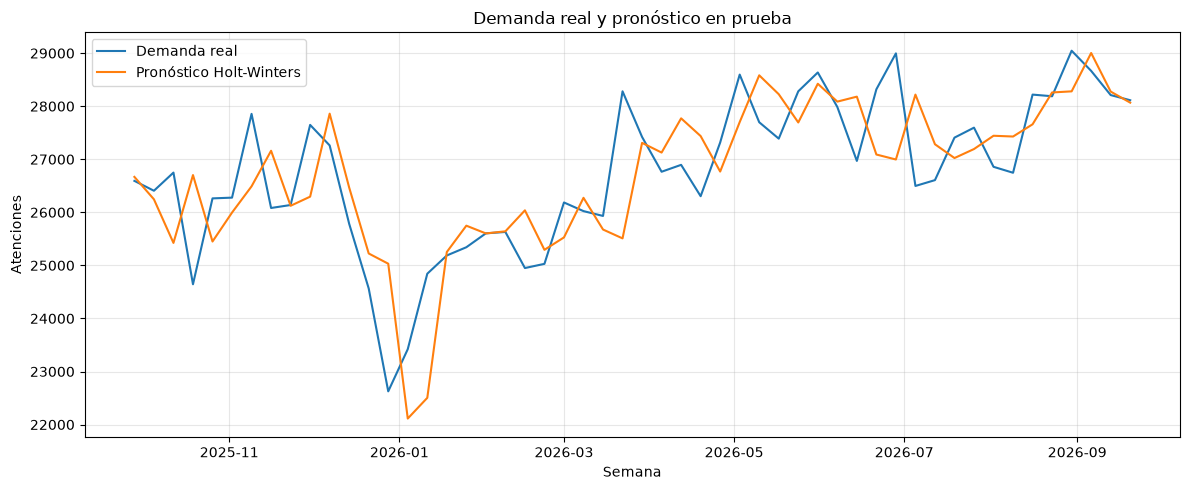

In [22]:
# Historial disponible antes de iniciar la prueba
historial_test = pd.concat([train, valid]).asfreq("W-SUN")
predicciones_test = []

for fecha, real in test.items():

    modelo_test = ExponentialSmoothing(
        historial_test / 1000,
        trend="add",
        seasonal="add",
        seasonal_periods=52,
        initialization_method="estimated"
    ).fit(optimized=True)

    # Primero pronosticamos; después incorporamos el dato real
    pronostico = float(modelo_test.forecast(1).iloc[0]) * 1000
    predicciones_test.append(pronostico)

    historial_test = pd.concat([
        historial_test,
        pd.Series([real], index=[fecha])
    ]).asfreq("W-SUN")

pred_test = pd.Series(
    predicciones_test,
    index=test.index,
    name="Pronóstico"
)

error_test = test - pred_test

metricas_test = pd.DataFrame({
    "MD": [error_test.mean()],
    "MAD": [error_test.abs().mean()],
    "MAPE (%)": [(error_test.abs() / test).mean() * 100],
    "RMSE": [error_test.pow(2).mean() ** 0.5]
}, index=["Holt-Winters aditivo"])

display(metricas_test.round(2))

plt.figure(figsize=(12, 5))
plt.plot(test.index, test, label="Demanda real")
plt.plot(pred_test.index, pred_test, label="Pronóstico Holt-Winters")
plt.title("Demanda real y pronóstico en prueba")
plt.xlabel("Semana")
plt.ylabel("Atenciones")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Resultados de prueba

Holt-Winters aditivo obtuvo un MAD de 761.22 atenciones por semana y un MAPE de 2.88% en las 52 semanas de prueba.

El MAD aumentó respecto a validación, donde fue de 628.23. Esto indica menor precisión durante el periodo de prueba. El MD de 23.07 muestra una ligera subestimación promedio, aunque los errores positivos y negativos pueden compensarse.

El RMSE de 1,011.94 refleja la presencia de errores grandes en algunas semanas. La gráfica muestra que el pronóstico sigue buena parte de las variaciones, pero presenta diferencias alrededor del cambio de año.

Estos resultados permiten evaluar el modelo seleccionado, pero no garantizan que el pronóstico cubra la demanda de cada semana. Por ello, se evaluará un buffer calculado con los errores de validación.

## Buffer para la planificación de capacidad

Se calcula un buffer utilizando el percentil 95 de los errores de validación de Holt-Winters, definidos como demanda real menos pronóstico.

El percentil se calcula sobre todos los errores, conservando su signo. Si el resultado es negativo, se utiliza un buffer de cero.

La capacidad objetivo semanal se obtiene sumando el buffer al pronóstico. Se compara con la demanda de prueba para medir cobertura, faltantes y capacidad sobrante.

Esta capacidad objetivo es un escenario expresado en atenciones semanales. Para convertirlo en personal, camas o turnos se necesitarían datos operativos adicionales.

In [23]:
# Buffer calculado únicamente con errores de validación
nivel_objetivo = 0.95
buffer = max(0.0, float(error_hw.quantile(nivel_objetivo)))

print(f"Buffer adicional: {buffer:,.2f} atenciones por semana")

# Evaluación del escenario en prueba
evaluacion_buffer = pd.DataFrame({
    "Demanda real": test,
    "Pronóstico": pred_test
})

evaluacion_buffer["Capacidad objetivo"] = (
    evaluacion_buffer["Pronóstico"] + buffer
)

evaluacion_buffer["Cubierta"] = (
    evaluacion_buffer["Demanda real"]
    <= evaluacion_buffer["Capacidad objetivo"]
)

evaluacion_buffer["Faltantes"] = (
    evaluacion_buffer["Demanda real"]
    - evaluacion_buffer["Capacidad objetivo"]
).clip(lower=0)

evaluacion_buffer["Sobrantes"] = (
    evaluacion_buffer["Capacidad objetivo"]
    - evaluacion_buffer["Demanda real"]
).clip(lower=0)

display(evaluacion_buffer.head(10).round(2))

# Comparación con y sin buffer
resumen_buffer = []

for escenario, capacidad in {
    "Sin buffer": pred_test,
    "Con buffer": evaluacion_buffer["Capacidad objetivo"]
}.items():

    faltantes = (test - capacidad).clip(lower=0)
    sobrantes = (capacidad - test).clip(lower=0)

    resumen_buffer.append({
        "Escenario": escenario,
        "Cobertura (%)": (test <= capacidad).mean() * 100,
        "Semanas con faltantes": int((faltantes > 0).sum()),
        "Faltantes totales": faltantes.sum(),
        "Sobrantes totales": sobrantes.sum()
    })

resumen_buffer = pd.DataFrame(resumen_buffer).set_index("Escenario")
display(resumen_buffer.round(2))

Buffer adicional: 1,234.82 atenciones por semana


,Demanda real,Pronóstico,Capacidad objetivo,Cubierta,Faltantes,Sobrantes
WeekEndingDate,,,,,,
2025-09-28,26593.0,26668.01,27902.82,True,0.00,1309.82
2025-10-05,26407.0,26245.48,27480.30,True,0.00,1073.30
2025-10-12,26749.0,25423.63,26658.45,False,90.55,0.00
2025-10-19,24644.0,26702.40,27937.22,True,0.00,3293.22
2025-10-26,26263.0,25450.09,26684.91,True,0.00,421.91
2025-11-02,26277.0,25995.72,27230.53,True,0.00,953.53
2025-11-09,27856.0,26489.89,27724.71,False,131.29,0.00
2025-11-16,26082.0,27160.52,28395.33,True,0.00,2313.33
2025-11-23,26138.0,26123.61,27358.43,True,0.00,1220.43


,Cobertura (%),Semanas con faltantes,Faltantes totales,Sobrantes totales
Escenario,,,,
Sin buffer,51.92,25,20391.45,19191.80
Con buffer,86.54,7,3819.74,66830.58


### Resultados del buffer

El buffer calculado con los errores de validación fue de 1,234.82 atenciones adicionales por semana.

En prueba, la cobertura aumentó de 51.92% a 86.54%, equivalente a cubrir la demanda en 45 de las 52 semanas. Las semanas con faltantes disminuyeron de 25 a 7 y los faltantes acumulados bajaron de 20,391.45 a 3,819.74 atenciones.

Esta mejora implicó aumentar la capacidad sobrante acumulada de 19,191.80 a 66,830.58 atenciones. Por tanto, existe un intercambio entre reducir faltantes y reservar capacidad que podría no utilizarse.

No se alcanzó la meta de cobertura del 95%. Se conserva este resultado sin ajustar el buffer con los datos de prueba. Una siguiente versión debería evaluar su estabilidad con varias ventanas temporales de validación.

Los faltantes y sobrantes representan diferencias del escenario de planificación; no son mediciones de pacientes sin atención ni de recursos hospitalarios realmente ociosos.

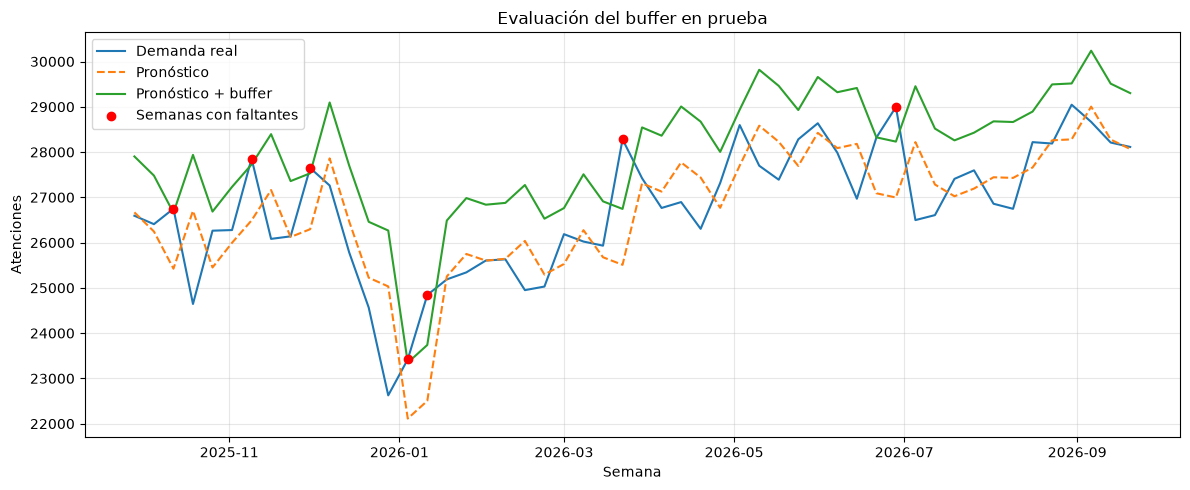

In [24]:
plt.figure(figsize=(12, 5))

plt.plot(test.index, test, label="Demanda real")
plt.plot(pred_test.index, pred_test, label="Pronóstico", linestyle="--")
plt.plot(
    evaluacion_buffer.index,
    evaluacion_buffer["Capacidad objetivo"],
    label="Pronóstico + buffer"
)

faltantes = ~evaluacion_buffer["Cubierta"]

plt.scatter(
    test.index[faltantes],
    test.loc[faltantes],
    color="red",
    label="Semanas con faltantes",
    zorder=5
)

plt.title("Evaluación del buffer en prueba")
plt.xlabel("Semana")
plt.ylabel("Atenciones")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()